In [1]:
#session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
#session = '/mnt/hubel-data-131/perceval/Rat003_20231215/Rat003_20231215.xml'
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'

In [2]:
import fmatoolbox as fma
import matplotlib.pyplot as plt
import numpy as np
import regions as rg
%load_ext autoreload
%autoreload 2

In [24]:
spikes = np.array([
    # Avalanche 1
    [5.00000000e-02, 3.00000000e+00],
    [6.20000000e-02, 7.00000000e+00],
    [7.80000000e-02, 2.00000000e+00],
    [9.10000000e-02, 9.00000000e+00],
    [1.05000000e-01, 4.00000000e+00],
    [1.18000000e-01, 6.00000000e+00],
    [1.32000000e-01, 1.00000000e+01],
    [1.47000000e-01, 5.00000000e+00],
    [1.61000000e-01, 8.00000000e+00],
    [1.76000000e-01, 2.00000000e+00],
    [1.92000000e-01, 7.00000000e+00],
    [2.08000000e-01, 4.00000000e+00],
    [2.23000000e-01, 9.00000000e+00],
    [2.39000000e-01, 6.00000000e+00],

    # (silence)

    # Avalanche 2
    [3.20000000e-01, 1.00000000e+00],
    [3.34000000e-01, 5.00000000e+00],
    [3.48000000e-01, 8.00000000e+00],
    [3.62000000e-01, 3.00000000e+00],
    [3.76000000e-01, 9.00000000e+00],
    [3.90000000e-01, 2.00000000e+00],
    [4.04000000e-01, 6.00000000e+00],
    [4.18000000e-01, 4.00000000e+00],
    [4.32000000e-01, 7.00000000e+00],
    [4.47000000e-01, 1.00000000e+01],
    [4.62000000e-01, 3.00000000e+00],
    [4.78000000e-01, 8.00000000e+00],
    [4.94000000e-01, 5.00000000e+00],
    [5.10000000e-01, 2.00000000e+00],
    [5.26000000e-01, 9.00000000e+00],
])

In [ ]:
from time import time


def avalanchesplot(session=None, spikes=None, FR=None, bin_size=0.05, neurons=None, tmax=50, threshold=30, smoothed=False, window=5, time_step=None):#neurons = nombre de neurones à prendre en compte, tmax = durée max à prendre en compte, threshold = seuil pour définir les avalanches, smoothed = si on veut afficher la courbe lissée, window = taille de la fenêtre pour le lissage 
    
    if spikes is None and session is None:
        return "Please provide either a session or spike times."
    if session is not None:
        spikes_indiv = fma.data.loadSpikeTimes(session)
    if spikes is not None:
        spikes_indiv = {}
        d = {}
        for value, neuron in spikes:
            neuron = np.uint(neuron)
            if neuron not in d:
                d[neuron] = []
            d[neuron].append(value)
        for neuron, values in d.items():
            spikes_indiv[neuron] = values
    if neurons is not None:
        spikes_indiv = dict(list(spikes_indiv.items())[:neurons])
    spikes_indiv = {key: fma.general.restrict(spikes_indiv[key], [0, tmax]) for key in spikes_indiv} 
    


    if spikes is None:
        spikes = fma.data.loadSpikeTimes(session, output='compact')
    if neurons is not None:
        ind = spikes[:,1] < neurons
        spikes = spikes[ind,:]
    spikes = spikes[(spikes[:,0] >= 0) & (spikes[:,0] <= tmax),:]
    if FR is None:
        FR = fma.analysis.firingRate(spikes[:,0], bin_size=bin_size)
    else:
        FR = FR[FR[:,0] <= tmax,:]
    time = FR[:, 0]
    rates = FR[:, 1]
    if smoothed:
        smoothed_rates = np.convolve(rates, np.ones(window)/window, mode='same')
    if time_step is None:
        time_step=FR[1,0] - FR[0,0]

    size, intervals, size_t = rg.computation.avalanchesFromProfile(
        rates,
        threshold=threshold,
        time_step=time_step,
        t0=FR[0,0]
    )

    print(intervals)
    print(f"tmax = {time[-1]}")
    

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,10), sharex=True)

    for n, (neuron_id, spike_times) in enumerate(spikes_indiv.items()):
    # transforme la liste en array si nécessaire
        spike_times = np.array(spike_times)
    
    # y = n pour ce neurone
        ax1.scatter(spike_times, 
                [neuron_id] * len(spike_times), 
                marker='|', 
                s=100,     # taille du trait
                color='black')
    
    for t1, t2 in intervals:
        ax1.axvspan(t1, t2, color='red', alpha=0.3)


    ax2.plot(time[:len(rates)] , rates, color='green', label='Firing rate')
    if smoothed:
        ax2.plot(time[:len(smoothed_rates)], smoothed_rates, color='blue', label='Smoothed firing rate')
    for t1, t2 in intervals:
        ax2.axvspan(t1, t2, color='red', alpha=0.3)

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Neuron Index")
    ax1.set_title("Spikes with avalanches")

    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Firing rate (Hz)")
    ax2.set_title("Firing rate (moving average) with avalanches")
    ax2.legend()

    
    plt.show()


In [80]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
R = rg.data.Regions(session,states=['sws','rem'],events=['ripples'])
spikes = R.spikes(regs=["nr"])
print(len(spikes))
fr = R.firingRate(regs=["nr"], window=0.005, step=1)
print(fr[:5])


4742146
[[2.50e-03 4.00e+02]
 [7.50e-03 2.00e+02]
 [1.25e-02 4.00e+02]
 [1.75e-02 0.00e+00]
 [2.25e-02 2.00e+02]]


500 500 500


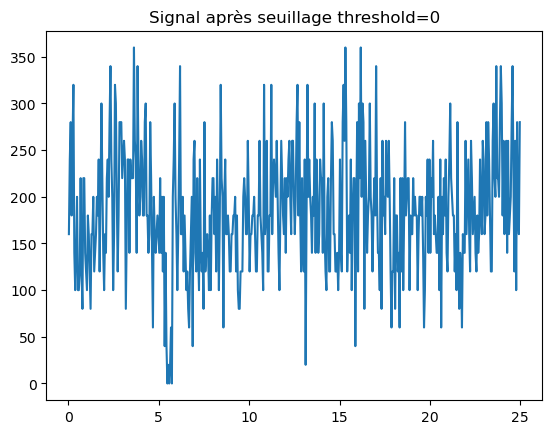

[[2.50000e-02 1.80000e+02]
 [7.50000e-02 2.60000e+02]
 [1.25000e-01 3.00000e+02]
 ...
 [4.04875e+02 4.00000e+01]
 [4.04925e+02 1.40000e+02]
 [4.04975e+02 2.20000e+02]]
[180. 260. 300. ... 200. 240. 240.]


In [ ]:
tmax = 25
FR = fr[fr[:,0] <= tmax,:]
rates = FR[:,1]
time=FR[:,0]
x = np.array(rates)
print(len(x), len(rates), len(FR))
threshold_val = np.percentile(x, 0)  # = min(x)
x_thresh = x - threshold_val
x_thresh[x_thresh < 0] = 0
plt.plot(time, x_thresh)
plt.title('Signal après seuillage threshold=0')
plt.show()

print(fr[(fr[:,0] <= 405) & (fr[:,1] > 4.4),:])

In [ ]:
avalanchesplot(session, spikes=spikes, FR=fr,tmax=10, smoothed=True, bin_size = 0.05, threshold=0, window=5)

TypeError: argument should be a str or an os.PathLike object where __fspath__ returns a str, not 'NoneType'

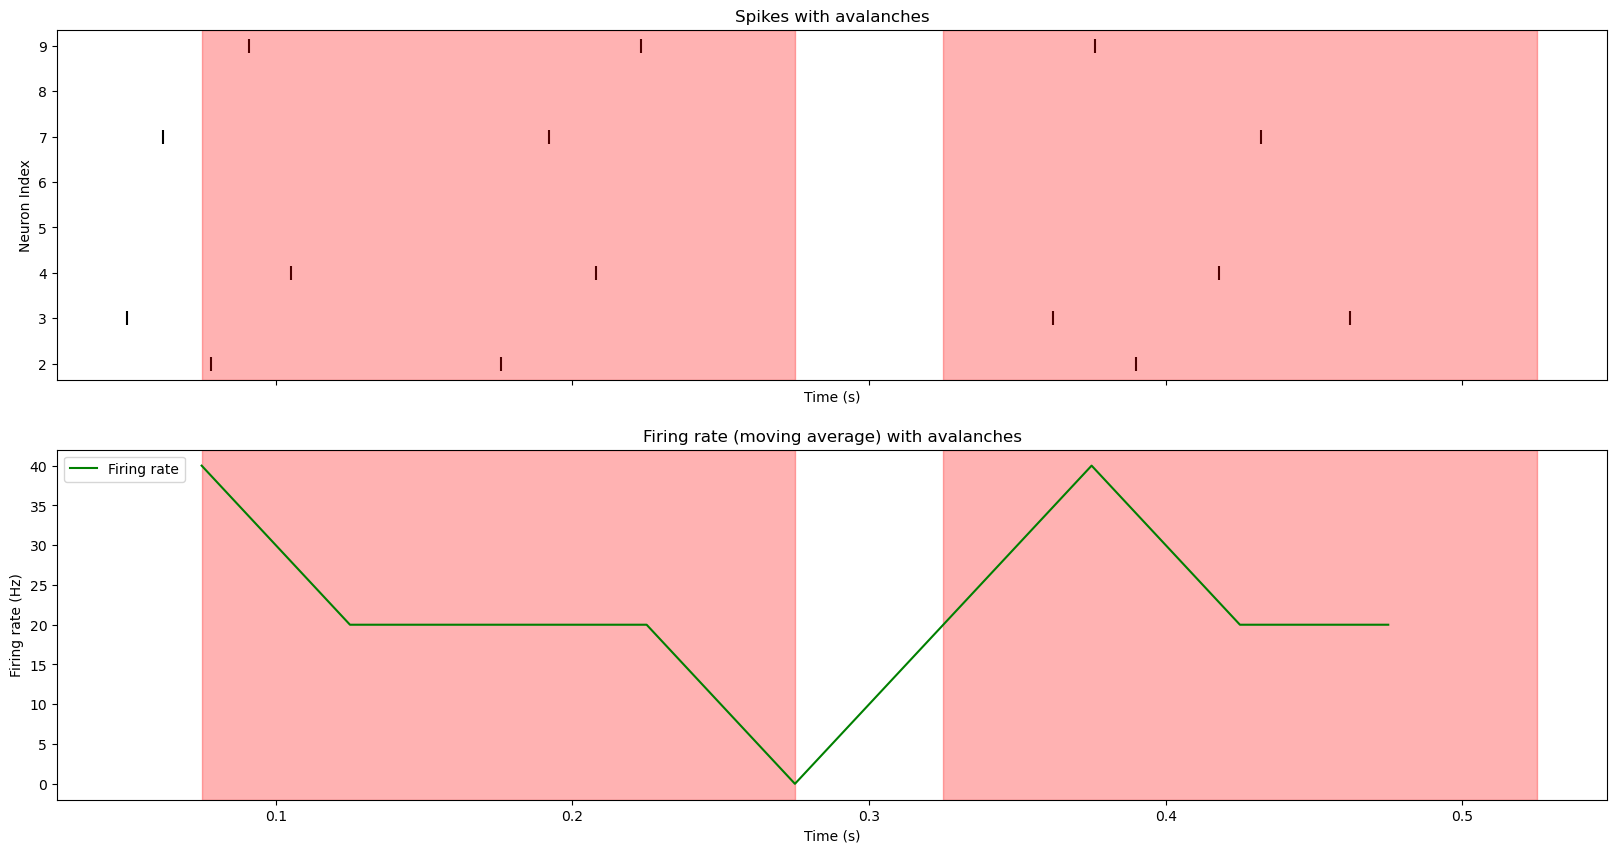

In [28]:
avalanchesplot(session, spikes, neurons=5, tmax=0.5, threshold=10)